<a href="https://colab.research.google.com/github/lianghuizi/Study/blob/main/mim_rae_dit_experiment_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAE latent attention adapters for a DiT diffusion model

This notebook is a self-contained Colab experiment for comparing:

- `baseline`: compact RAE-style latent autoencoder + latent DiT
- `channel_se`: Channel Attention + SE adapter injected into DiT blocks
- `mim4`: MiM-style four expert adapter with Spatial, Channel, Swin-like local, and SE experts

The default `QUICK=True` mode is for shape checks, training stability, and first sample grids. For a meaningful generation comparison, set `QUICK=False`, use a larger GPU runtime, and raise the epochs.

The autoencoder here is intentionally compact so the notebook can run without an external repository. To use a real pretrained RAE, replace `SmallRAE.encode` and `SmallRAE.decode` with your RAE encoder/decoder and keep the latent tensor shape contract `[B, C, H, W]`.

In [1]:
import math
import os
import random
import time
from dataclasses import dataclass, asdict
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

def seed_everything(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: Tesla T4


In [2]:
@dataclass
class Config:
    quick: bool = True
    data_root: str = "/content/data"
    out_dir: str = "/content/mim_rae_dit_runs"
    image_size: int = 32
    latent_channels: int = 64
    ae_epochs: int = 2
    dit_epochs: int = 2
    dataset_size: int = 10000
    val_size: int = 1000
    batch_size: int = 128
    lr_ae: float = 2e-4
    lr_dit: float = 2e-4
    timesteps: int = 1000
    sample_steps: int = 50
    dit_dim: int = 256
    dit_depth: int = 6
    dit_heads: int = 4
    mlp_ratio: float = 4.0
    variants: tuple = ("baseline", "channel_se", "mim4")

cfg = Config()

if not cfg.quick:
    cfg.dataset_size = 50000
    cfg.val_size = 5000
    cfg.batch_size = 128
    cfg.ae_epochs = 20
    cfg.dit_epochs = 50
    cfg.dit_dim = 384
    cfg.dit_depth = 8
    cfg.sample_steps = 100

Path(cfg.out_dir).mkdir(parents=True, exist_ok=True)
print(asdict(cfg))

{'quick': True, 'data_root': '/content/data', 'out_dir': '/content/mim_rae_dit_runs', 'image_size': 32, 'latent_channels': 64, 'ae_epochs': 2, 'dit_epochs': 2, 'dataset_size': 10000, 'val_size': 1000, 'batch_size': 128, 'lr_ae': 0.0002, 'lr_dit': 0.0002, 'timesteps': 1000, 'sample_steps': 50, 'dit_dim': 256, 'dit_depth': 6, 'dit_heads': 4, 'mlp_ratio': 4.0, 'variants': ('baseline', 'channel_se', 'mim4')}


## Dataset

The experiment uses CIFAR-10 for a fast end-to-end run. Images are normalized to `[-1, 1]`. Replace this section with your target image restoration / generation dataset when you move beyond the first sanity check.

100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


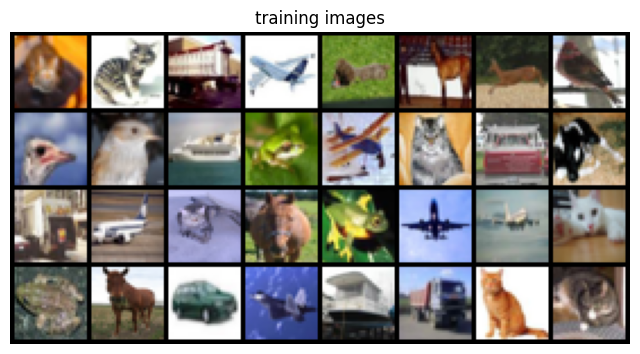

In [3]:
transform = transforms.Compose([
    transforms.Resize(cfg.image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full = datasets.CIFAR10(root=cfg.data_root, train=True, transform=transform, download=True)
idx = list(range(min(cfg.dataset_size + cfg.val_size, len(full))))
subset = Subset(full, idx)
train_set, val_set = random_split(
    subset,
    [len(subset) - cfg.val_size, cfg.val_size],
    generator=torch.Generator().manual_seed(42),
)
train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_set, batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True, drop_last=False)

def show_grid(x, title="", nrow=8):
    x = (x.detach().cpu().clamp(-1, 1) + 1) * 0.5
    grid = utils.make_grid(x, nrow=nrow)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(title)
    plt.show()

images, _ = next(iter(train_loader))
show_grid(images[:32], "training images")

## Compact RAE-style autoencoder

This is not meant to be the final RAE. It gives us a high-dimensional latent tensor so we can test whether attention adapters improve latent diffusion training. A real RAE swap only needs to preserve:

```python
z = ae.encode(images)      # [B, C, H, W]
images = ae.decode(z)      # [B, 3, H_img, W_img]
```

In [4]:
class ResBlock2d(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.GroupNorm(8, channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x):
        return x + self.net(x)


class SmallRAE(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            ResBlock2d(64),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            ResBlock2d(128),
            nn.Conv2d(128, latent_channels, 4, stride=2, padding=1),
            ResBlock2d(latent_channels),
        )
        self.decoder = nn.Sequential(
            ResBlock2d(latent_channels),
            nn.ConvTranspose2d(latent_channels, 128, 4, stride=2, padding=1),
            ResBlock2d(128),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            ResBlock2d(64),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv2d(64, 3, 3, padding=1),
            nn.Tanh(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))


ae = SmallRAE(cfg.latent_channels).to(device)
print("latent shape:", ae.encode(images[:2].to(device)).shape)

latent shape: torch.Size([2, 64, 8, 8])


AE epoch 1/2:   0%|          | 0/78 [00:00<?, ?it/s]

{'epoch': 1, 'train': 0.20014093109430411, 'val': 0.12543146591633558}


AE epoch 2/2:   0%|          | 0/78 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e80251e9800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
       Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7e80251e9800> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^^    self._shutdown_workers()^^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^^    if w.is_alive():^
^^^  ^ ^^ ^ ^  ^^^^^^^^^

{'epoch': 2, 'train': 0.10574423645933469, 'val': 0.09002283494919538}
saved /content/mim_rae_dit_runs/small_rae.pt


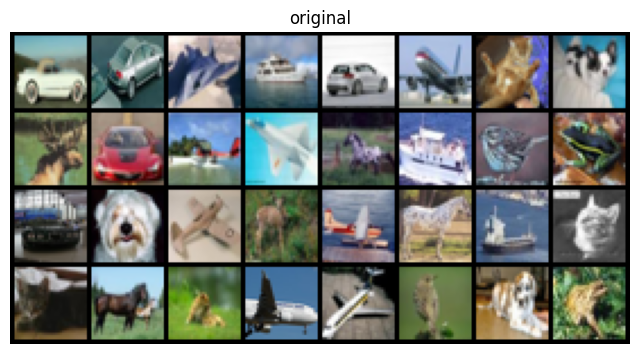

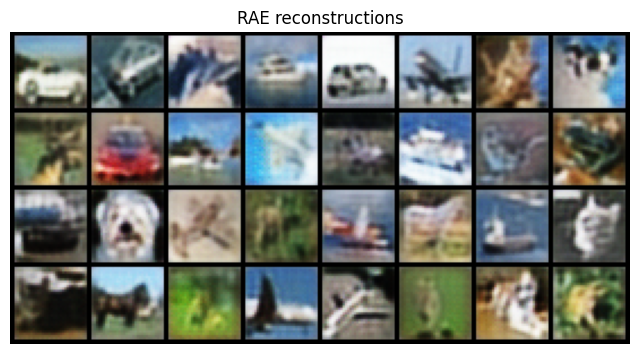

In [5]:
def train_autoencoder(ae, train_loader, val_loader, epochs):
    opt = torch.optim.AdamW(ae.parameters(), lr=cfg.lr_ae, weight_decay=1e-4)
    history = []
    for epoch in range(1, epochs + 1):
        ae.train()
        running = 0.0
        pbar = tqdm(train_loader, desc=f"AE epoch {epoch}/{epochs}")
        for x, _ in pbar:
            x = x.to(device, non_blocking=True)
            recon = ae(x)
            loss = F.l1_loss(recon, x) + 0.25 * F.mse_loss(recon, x)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(ae.parameters(), 1.0)
            opt.step()
            running += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        ae.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device, non_blocking=True)
                recon = ae(x)
                val_loss += (F.l1_loss(recon, x) + 0.25 * F.mse_loss(recon, x)).item()
        val_loss /= len(val_loader)
        history.append({"epoch": epoch, "train": running / len(train_loader), "val": val_loss})
        print(history[-1])
    return history


ae_ckpt = Path(cfg.out_dir) / "small_rae.pt"
if ae_ckpt.exists():
    ae.load_state_dict(torch.load(ae_ckpt, map_location=device))
    print("loaded", ae_ckpt)
else:
    ae_history = train_autoencoder(ae, train_loader, val_loader, cfg.ae_epochs)
    torch.save(ae.state_dict(), ae_ckpt)
    print("saved", ae_ckpt)

ae.eval()
with torch.no_grad():
    x, _ = next(iter(val_loader))
    x = x[:32].to(device)
    recon = ae(x)
show_grid(x, "original")
show_grid(recon, "RAE reconstructions")

## Latent normalization and diffusion schedule

The diffusion model trains on standardized latents. Keep these statistics with the checkpoint, otherwise generated latents will decode poorly.

In [6]:
@torch.no_grad()
def compute_latent_stats(ae, loader, max_batches=100):
    ae.eval()
    sums = 0.0
    sq_sums = 0.0
    count = 0
    for i, (x, _) in enumerate(tqdm(loader, desc="latent stats")):
        if i >= max_batches:
            break
        z = ae.encode(x.to(device, non_blocking=True))
        sums += z.sum(dim=(0, 2, 3))
        sq_sums += (z ** 2).sum(dim=(0, 2, 3))
        count += z.shape[0] * z.shape[2] * z.shape[3]
    mean = sums / count
    var = sq_sums / count - mean ** 2
    std = var.clamp_min(1e-6).sqrt()
    return mean.view(1, -1, 1, 1), std.view(1, -1, 1, 1)

latent_mean, latent_std = compute_latent_stats(ae, train_loader)
latent_mean = latent_mean.to(device)
latent_std = latent_std.to(device)
print("latent mean/std:", latent_mean.mean().item(), latent_std.mean().item())

def encode_norm(x):
    return (ae.encode(x) - latent_mean) / latent_std

def decode_norm(z):
    return ae.decode(z * latent_std + latent_mean)


def make_beta_schedule(timesteps):
    return torch.linspace(1e-4, 0.02, timesteps)

betas = make_beta_schedule(cfg.timesteps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

def extract(a, t, x_shape):
    out = a.gather(0, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

def q_sample(x0, t, noise):
    sqrt_ab = extract(alphas_cumprod.sqrt(), t, x0.shape)
    sqrt_omab = extract((1.0 - alphas_cumprod).sqrt(), t, x0.shape)
    return sqrt_ab * x0 + sqrt_omab * noise

latent stats:   0%|          | 0/78 [00:00<?, ?it/s]

latent mean/std: 0.04825470596551895 1.046169638633728


## DiT backbone and attention adapters

The adapters are zero-projected before residual injection. This lets the baseline DiT path start unchanged, while the adapter gradually learns useful latent priors.

In [7]:
def modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)


class TimestepEmbedder(nn.Module):
    def __init__(self, dim, freq_dim=256):
        super().__init__()
        self.freq_dim = freq_dim
        self.mlp = nn.Sequential(nn.Linear(freq_dim, dim), nn.SiLU(), nn.Linear(dim, dim))

    def forward(self, t):
        half = self.freq_dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if self.freq_dim % 2:
            emb = F.pad(emb, (0, 1))
        return self.mlp(emb)


class DiTBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hidden), nn.GELU(), nn.Linear(hidden, dim))
        self.ada = nn.Sequential(nn.SiLU(), nn.Linear(dim, 6 * dim))
        nn.init.zeros_(self.ada[-1].weight)
        nn.init.zeros_(self.ada[-1].bias)

    def forward(self, x, t_emb):
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = self.ada(t_emb).chunk(6, dim=-1)
        h = modulate(self.norm1(x), shift_msa, scale_msa)
        h, _ = self.attn(h, h, h, need_weights=False)
        x = x + gate_msa.unsqueeze(1) * h
        h = self.mlp(modulate(self.norm2(x), shift_mlp, scale_mlp))
        x = x + gate_mlp.unsqueeze(1) * h
        return x


class FinalLayer(nn.Module):
    def __init__(self, dim, out_dim):
        super().__init__()
        self.norm = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.ada = nn.Sequential(nn.SiLU(), nn.Linear(dim, 2 * dim))
        self.linear = nn.Linear(dim, out_dim)
        nn.init.zeros_(self.ada[-1].weight)
        nn.init.zeros_(self.ada[-1].bias)
        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x, t_emb):
        shift, scale = self.ada(t_emb).chunk(2, dim=-1)
        return self.linear(modulate(self.norm(x), shift, scale))

In [8]:
class ZeroProject(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.proj = nn.Linear(dim, dim)
        nn.init.zeros_(self.proj.weight)
        nn.init.zeros_(self.proj.bias)

    def forward(self, x):
        return self.proj(x)


class SEExpert(nn.Module):
    def __init__(self, dim, reduction=4):
        super().__init__()
        hidden = max(16, dim // reduction)
        self.net = nn.Sequential(nn.Linear(dim, hidden), nn.SiLU(), nn.Linear(hidden, dim), nn.Sigmoid())

    def forward(self, x):
        gate = self.net(x.mean(dim=1)).unsqueeze(1)
        return x * gate


class SpatialExpert(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)

    def forward(self, x):
        h = self.norm(x)
        h, _ = self.attn(h, h, h, need_weights=False)
        return h


class ChannelExpert(nn.Module):
    def __init__(self, dim, num_tokens, heads=4):
        super().__init__()
        safe_heads = min(heads, num_tokens)
        while num_tokens % safe_heads != 0 and safe_heads > 1:
            safe_heads -= 1
        self.norm = nn.LayerNorm(num_tokens)
        self.attn = nn.MultiheadAttention(num_tokens, safe_heads, batch_first=True)
        self.proj = nn.Linear(num_tokens, num_tokens)

    def forward(self, x):
        # x: [B, spatial_tokens, channels]. Attend over channel tokens using spatial positions as features.
        y = x.transpose(1, 2)
        y = self.norm(y)
        y, _ = self.attn(y, y, y, need_weights=False)
        y = self.proj(y)
        return y.transpose(1, 2)


class SwinLikeExpert(nn.Module):
    def __init__(self, dim, heads, grid_size, window=4):
        super().__init__()
        self.grid_size = grid_size
        self.window = min(window, grid_size)
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)

    def forward(self, x):
        b, n, c = x.shape
        g = self.grid_size
        w = self.window
        h = self.norm(x).view(b, g, g, c)
        windows = h.view(b, g // w, w, g // w, w, c).permute(0, 1, 3, 2, 4, 5).reshape(-1, w * w, c)
        windows, _ = self.attn(windows, windows, windows, need_weights=False)
        h = windows.view(b, g // w, g // w, w, w, c).permute(0, 1, 3, 2, 4, 5).reshape(b, g, g, c)
        return h.view(b, n, c)


class ChannelSEAdapter(nn.Module):
    def __init__(self, dim, num_tokens):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.channel = ChannelExpert(dim, num_tokens)
        self.se = SEExpert(dim)
        self.ff = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, 4 * dim), nn.GELU(), nn.Linear(4 * dim, dim))
        self.out = ZeroProject(dim)

    def forward(self, x):
        h = self.norm(x)
        h = h + self.channel(h)
        h = self.se(h)
        h = h + self.ff(h)
        return self.out(h)


class SparseIntraMoE(nn.Module):
    def __init__(self, experts, dim, top_k=2):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.router = nn.Linear(dim, len(experts))
        self.top_k = min(top_k, len(experts))

    def forward(self, x):
        # Keep routing logits in fp32 under AMP. A large negative mask such as
        # -1e9 overflows in fp16, which breaks the MiM sparse router.
        logits = self.router(x.mean(dim=1)).float()
        top_vals, top_idx = logits.topk(self.top_k, dim=-1)
        sparse = torch.full_like(logits, torch.finfo(logits.dtype).min)
        sparse.scatter_(1, top_idx, top_vals)
        weights = sparse.softmax(dim=-1).to(x.dtype)
        ys = torch.stack([expert(x) for expert in self.experts], dim=1)
        return (ys * weights[:, :, None, None]).sum(dim=1)


class MiM4Adapter(nn.Module):
    def __init__(self, dim, num_tokens, heads, grid_size):
        super().__init__()
        self.inter_router = nn.Linear(dim, 4)
        self.spatial = SparseIntraMoE([SpatialExpert(dim, heads) for _ in range(2)], dim)
        self.channel = SparseIntraMoE([ChannelExpert(dim, num_tokens) for _ in range(2)], dim)
        self.swin = SparseIntraMoE([SwinLikeExpert(dim, heads, grid_size) for _ in range(2)], dim)
        self.se = SparseIntraMoE([SEExpert(dim) for _ in range(2)], dim)
        self.out = ZeroProject(dim)

    def forward(self, x):
        weights = self.inter_router(x.mean(dim=1)).softmax(dim=-1)
        ys = torch.stack([self.spatial(x), self.channel(x), self.swin(x), self.se(x)], dim=1)
        y = (ys * weights[:, :, None, None]).sum(dim=1)
        return self.out(y)

In [9]:
class LatentDiT(nn.Module):
    def __init__(self, latent_channels, latent_size, dim, depth, heads, adapter="baseline"):
        super().__init__()
        self.latent_channels = latent_channels
        self.latent_size = latent_size
        self.num_tokens = latent_size * latent_size
        self.x_embed = nn.Linear(latent_channels, dim)
        self.pos = nn.Parameter(torch.zeros(1, self.num_tokens, dim))
        nn.init.normal_(self.pos, std=0.02)
        self.t_embed = TimestepEmbedder(dim)
        self.blocks = nn.ModuleList([DiTBlock(dim, heads, cfg.mlp_ratio) for _ in range(depth)])
        self.final = FinalLayer(dim, latent_channels)
        self.adapter_type = adapter
        adapters = []
        for _ in range(depth):
            if adapter == "baseline":
                adapters.append(nn.Identity())
            elif adapter == "channel_se":
                adapters.append(ChannelSEAdapter(dim, self.num_tokens))
            elif adapter == "mim4":
                adapters.append(MiM4Adapter(dim, self.num_tokens, heads, latent_size))
            else:
                raise ValueError(f"unknown adapter: {adapter}")
        self.adapters = nn.ModuleList(adapters)

    def forward(self, z, t):
        b, c, h, w = z.shape
        x = z.flatten(2).transpose(1, 2)
        x = self.x_embed(x) + self.pos
        t_emb = self.t_embed(t)
        for block, adapter in zip(self.blocks, self.adapters):
            if self.adapter_type != "baseline":
                x = x + adapter(x)
            x = block(x, t_emb)
        x = self.final(x, t_emb)
        return x.transpose(1, 2).view(b, c, h, w)


with torch.no_grad():
    z = encode_norm(images[:2].to(device))
latent_size = z.shape[-1]
for variant in cfg.variants:
    m = LatentDiT(cfg.latent_channels, latent_size, cfg.dit_dim, cfg.dit_depth, cfg.dit_heads, variant).to(device)
    y = m(z, torch.randint(0, cfg.timesteps, (z.shape[0],), device=device))
    print(variant, "params:", sum(p.numel() for p in m.parameters()) / 1e6, "M", "out:", y.shape)
    del m
torch.cuda.empty_cache()

baseline params: 7.413568 M out: torch.Size([2, 64, 8, 8])
channel_se params: 11.291968 M out: torch.Size([2, 64, 8, 8])
mim4 params: 14.803336 M out: torch.Size([2, 64, 8, 8])


## Train and compare variants

Each variant gets the same training loop and validation denoising objective. In quick mode, the losses only tell us whether the adapter is learning and stable. For real comparison, run longer and compare sample grids over repeated seeds.

In [10]:
@torch.no_grad()
def val_denoise_loss(model, loader, max_batches=20):
    model.eval()
    losses = []
    for i, (x, _) in enumerate(loader):
        if i >= max_batches:
            break
        x = x.to(device, non_blocking=True)
        z0 = encode_norm(x)
        noise = torch.randn_like(z0)
        t = torch.randint(0, cfg.timesteps, (z0.shape[0],), device=device)
        zt = q_sample(z0, t, noise)
        pred = model(zt, t)
        losses.append(F.mse_loss(pred, noise).item())
    return sum(losses) / len(losses)


def train_dit_variant(variant):
    model = LatentDiT(cfg.latent_channels, latent_size, cfg.dit_dim, cfg.dit_depth, cfg.dit_heads, variant).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr_dit, weight_decay=0.03)
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    logs = []
    for epoch in range(1, cfg.dit_epochs + 1):
        model.train()
        running = 0.0
        pbar = tqdm(train_loader, desc=f"{variant} DiT epoch {epoch}/{cfg.dit_epochs}")
        for x, _ in pbar:
            x = x.to(device, non_blocking=True)
            with torch.no_grad():
                z0 = encode_norm(x)
            noise = torch.randn_like(z0)
            t = torch.randint(0, cfg.timesteps, (z0.shape[0],), device=device)
            zt = q_sample(z0, t, noise)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                pred = model(zt, t)
                loss = F.mse_loss(pred, noise)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            running += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        val_loss = val_denoise_loss(model, val_loader)
        row = {"variant": variant, "epoch": epoch, "train": running / len(train_loader), "val": val_loss}
        logs.append(row)
        print(row)
    ckpt = Path(cfg.out_dir) / f"dit_{variant}.pt"
    torch.save({"model": model.state_dict(), "cfg": asdict(cfg), "latent_mean": latent_mean.cpu(), "latent_std": latent_std.cpu()}, ckpt)
    return model, logs


results = {}
models = {}
for variant in cfg.variants:
    model, logs = train_dit_variant(variant)
    models[variant] = model
    results[variant] = logs

baseline DiT epoch 1/2:   0%|          | 0/78 [00:00<?, ?it/s]

{'variant': 'baseline', 'epoch': 1, 'train': 0.4937801149028998, 'val': 0.16488482058048248}


baseline DiT epoch 2/2:   0%|          | 0/78 [00:00<?, ?it/s]

{'variant': 'baseline', 'epoch': 2, 'train': 0.1538981441885997, 'val': 0.14317198656499386}


channel_se DiT epoch 1/2:   0%|          | 0/78 [00:00<?, ?it/s]

...

{'variant': 'channel_se', 'epoch': 2, 'train': 0.13659701668299162, 'val': 0.1309318095445633}


mim4 DiT epoch 1/2:   0%|          | 0/78 [00:00<?, ?it/s]

{'variant': 'mim4', 'epoch': 1, 'train': 0.49169943596308047, 'val': 0.1562096793204546}


mim4 DiT epoch 2/2:   0%|          | 0/78 [00:00<?, ?it/s]

{'variant': 'mim4', 'epoch': 2, 'train': 0.1486838072156295, 'val': 0.12516043428331614}


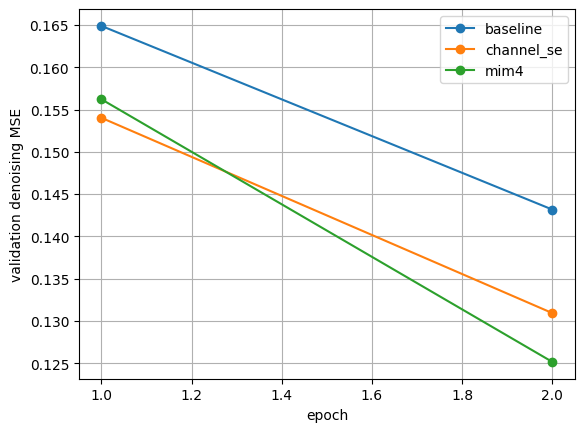

final validation losses
baseline 0.14317198656499386
channel_se 0.1309318095445633
mim4 0.12516043428331614


In [11]:
for variant, logs in results.items():
    xs = [r["epoch"] for r in logs]
    ys = [r["val"] for r in logs]
    plt.plot(xs, ys, marker="o", label=variant)
plt.xlabel("epoch")
plt.ylabel("validation denoising MSE")
plt.legend()
plt.grid(True)
plt.show()

print("final validation losses")
for variant, logs in results.items():
    print(variant, logs[-1]["val"])

## Sampling

This uses deterministic DDIM-style sampling. Early quick-mode samples will look rough; use them mainly to catch collapsed or unstable variants.

sampling:   0%|          | 0/50 [00:00<?, ?it/s]

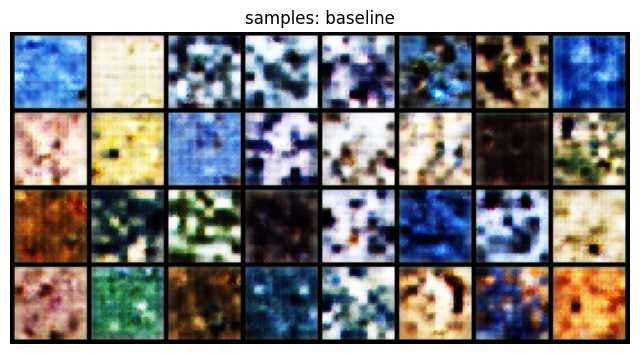

sampling:   0%|          | 0/50 [00:00<?, ?it/s]

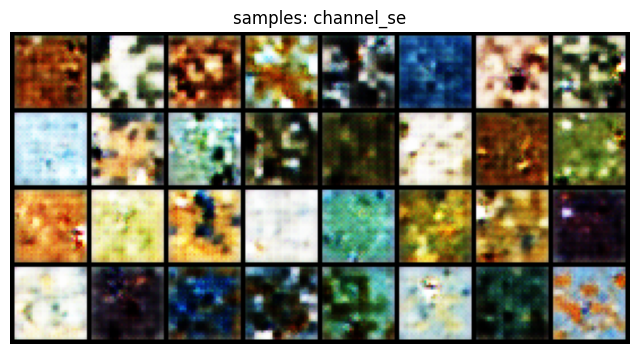

sampling:   0%|          | 0/50 [00:00<?, ?it/s]

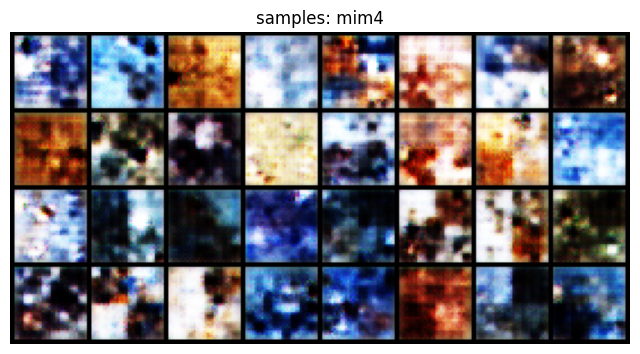

In [12]:
@torch.no_grad()
def ddim_sample(model, shape, steps=50):
    model.eval()
    z = torch.randn(shape, device=device)
    times = torch.linspace(cfg.timesteps - 1, 0, steps, device=device).long()
    for i, t_scalar in enumerate(tqdm(times, desc="sampling")):
        t = torch.full((shape[0],), int(t_scalar.item()), device=device, dtype=torch.long)
        eps = model(z, t)
        alpha_t = extract(alphas_cumprod, t, z.shape)
        pred_x0 = (z - (1 - alpha_t).sqrt() * eps) / alpha_t.sqrt()
        if i == len(times) - 1:
            z = pred_x0
        else:
            t_next = torch.full((shape[0],), int(times[i + 1].item()), device=device, dtype=torch.long)
            alpha_next = extract(alphas_cumprod, t_next, z.shape)
            z = alpha_next.sqrt() * pred_x0 + (1 - alpha_next).sqrt() * eps
    return z


sample_shape = (32, cfg.latent_channels, latent_size, latent_size)
for variant, model in models.items():
    z = ddim_sample(model, sample_shape, steps=cfg.sample_steps)
    x = decode_norm(z)
    show_grid(x, f"samples: {variant}")
    utils.save_image((x.clamp(-1, 1) + 1) * 0.5, Path(cfg.out_dir) / f"samples_{variant}.png", nrow=8)

## What to try next

Recommended progression:

1. Keep `quick=True` and verify all three variants run without shape errors.
2. Set `cfg.variants = ("baseline", "channel_se")` and `quick=False` for the first serious comparison.
3. Add `"mim4"` after the Channel+SE variant proves stable.
4. Replace `SmallRAE` with a real pretrained RAE. Keep the latent normalization cell.
5. For restoration, concatenate or cross-condition low-quality latent features into the adapter routers, then report PSNR/SSIM/LPIPS alongside sample grids.

Interpretation guide:

- If `channel_se` lowers validation denoising loss faster than `baseline`, the RAE latent likely has useful channel structure.
- If `mim4` beats `channel_se`, the four expert groups are learning complementary priors.
- If `mim4` is worse in quick mode, try fewer experts, lower router LR, or train Channel+SE first and warm-start the DiT backbone.